# Multi-Task Learning — một mạng, ba đầu ra (Linear + Logistic + Softmax) trên Diamonds

Đây là notebook **tổng hợp** của thư mục này. Ba notebook cùng thư mục đã giải quyết riêng lẻ ba mô hình trên cùng bộ dữ liệu Diamonds:

- `Linear_Regression_Diamonds.ipynb` — dự đoán `price` (nhãn **liên tục**)
- `Logistic_Regression_Diamonds.ipynb` — phân loại nhị phân "có phải cắt Ideal?" (nhãn **rời rạc**, nhị phân hoá từ `cut`)
- `Softmax_Regression_Diamonds.ipynb` — phân loại đầy đủ 5 mức `cut` (nhãn **rời rạc**, đa lớp)

Ba notebook đó dùng ba **mô hình tuyến tính độc lập**, mỗi mô hình một bộ trọng số riêng. Notebook này trả lời câu hỏi: **có thể xử lý cả ba nhiệm vụ cùng lúc, bằng MỘT mô hình, chia sẻ một biểu diễn chung không?** Đây là ý tưởng cốt lõi của **multi-task learning**: một mạng "thân" (trunk) học biểu diễn chung từ dữ liệu, rồi ba "đầu" (head) nhỏ gắn lên thân đó, mỗi đầu chuyên trách một nhiệm vụ.

**Vì sao Diamonds hợp bài toán này?** Bộ dữ liệu chỉ cần đúng **2 cột nhãn** — `price` (liên tục) và `cut` (rời rạc, 5 mức) — nhưng cột `cut` được dùng theo **hai cách khác nhau**: nguyên dạng 5 lớp cho Softmax, và nhị phân hoá ("Ideal" hay không) cho Logistic. Cả ba nhiệm vụ cùng chia sẻ 8 đặc trưng vật lý/chất lượng của viên kim cương — carat, độ sâu, bán kính bàn mặt, kích thước x/y/z, màu, độ trong — nên một biểu diễn ẩn học được từ các đặc trưng này **có tiềm năng hữu ích cho cả ba nhiệm vụ đồng thời**.

## 0. Quy trình 4 giai đoạn — khai ở đâu

| Giai đoạn | Nội dung | Mục |
|---|---|---|
| **1. Giải tay** | Kiến trúc "thân chia sẻ + 3 đầu" + hàm mất mát kết hợp $\mathcal{L} = \mathcal{L}_{MSE} + \mathcal{L}_{BCE} + \mathcal{L}_{CE}$; công thức từng nhiệm vụ (Linear/Logistic/Softmax) đã giải chi tiết ở 3 notebook anh em | §2 |
| **2. Bản thuần** | NumPy thuần: MLP 1 lớp ẩn, lan truyền ngược viết tay qua CẢ 3 đầu ra, cập nhật bằng SGD có động lượng (momentum) | §3 |
| **3. Bản thư viện** | `scikit-learn`: `MLPRegressor` + 2×`MLPClassifier` — huấn luyện **độc lập** (sklearn không có API multi-task thân-chia-sẻ sẵn) → đây là đường mốc "thư viện, không multi-task" để đo lợi ích thực sự của việc chia sẻ biểu diễn | §4 |
| **4. Framework** | `PyTorch`: một `nn.Module` với thân chia sẻ + 3 đầu, huấn luyện **đồng thời** bằng lan truyền ngược tự động (autograd) và tối ưu Adam | §5 |
| **So sánh** | Bảng + biểu đồ: 3 mô hình tuyến tính riêng lẻ vs bản thuần multi-task vs 3 MLP độc lập (thư viện) vs multi-task PyTorch | §6 |
| **Đa dạng cách áp dụng** | (a) suy luận 1 lượt cho dữ liệu mới, (b) tìm kim cương tương tự qua không gian embedding, (c) điều chỉnh ngưỡng quyết định theo mục tiêu kinh doanh | §7 |

## 1. Nạp dữ liệu (giống hệt 3 notebook anh em — bắt buộc để so sánh công bằng)

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score, f1_score, accuracy_score

np.random.seed(0)
_cands = ["data/diamonds.csv", "../data/diamonds.csv",
          "/home/alexdev/Projects/learning-master-ute/ml_ad/b8/data/diamonds.csv"]
CSV = next((p for p in _cands if os.path.exists(p)), _cands[0])
df = pd.read_csv(CSV)
df = df[(df.x > 0) & (df.y > 0) & (df.z > 0)].reset_index(drop=True)   # bo 20 dong loi (kich thuoc = 0)
print("Kich thuoc sau lam sach:", df.shape)

color_order = {c: i for i, c in enumerate(["J", "I", "H", "G", "F", "E", "D"])}
clarity_order = {c: i for i, c in enumerate(["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"])}
cut_order = {c: i for i, c in enumerate(["Fair", "Good", "Very Good", "Premium", "Ideal"])}
df["color_ord"] = df["color"].map(color_order)
df["clarity_ord"] = df["clarity"].map(clarity_order)
df["cut_ord"] = df["cut"].map(cut_order)

FEAT_COLS = ["carat", "depth", "table", "x", "y", "z", "color_ord", "clarity_ord"]
X = df[FEAT_COLS].values.astype(float)
y_price = df["price"].values.astype(float)           # nhan LIEN TUC
y_bin = (df["cut"] == "Ideal").astype(int).values     # nhan ROI RAC (nhi phan)
y_multi = df["cut_ord"].values                        # nhan ROI RAC (5 lop)

Xtr, Xte, ptr, pte, btr, bte, mtr, mte = train_test_split(
    X, y_price, y_bin, y_multi, test_size=0.2, random_state=1, stratify=y_multi
)
mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd
pmu, psd = ptr.mean(), ptr.std()
ptr_s, pte_s = (ptr - pmu) / psd, (pte - pmu) / psd
print("train/test:", len(ptr), len(pte), "| 8 dac trung dung chung:", FEAT_COLS)
print("Nhan lien tuc (price): mean=%.0f std=%.0f" % (ptr.mean(), ptr.std()))
print("Nhan roi rac nhi phan (is Ideal): ti le duong =", round(btr.mean(), 3))
print("Nhan roi rac 5 lop (cut):", pd.Series(mtr).value_counts().sort_index().to_dict())

Kich thuoc sau lam sach: (53920, 10)
train/test: 43136 10784 | 8 dac trung dung chung: ['carat', 'depth', 'table', 'x', 'y', 'z', 'color_ord', 'clarity_ord']
Nhan lien tuc (price): mean=3925 std=3987
Nhan roi rac nhi phan (is Ideal): ti le duong = 0.4
Nhan roi rac 5 lop (cut): {0: 1287, 1: 3922, 2: 9665, 3: 11024, 4: 17238}


## 2. Giải tay — kiến trúc "thân chia sẻ + 3 đầu"

**So với 3 notebook anh em:** mỗi notebook đó học một hàm tuyến tính RIÊNG $\hat{y} = w^\top x + b$ cho từng nhiệm vụ. Ở đây, ta chèn một lớp ẩn phi tuyến $h = \mathrm{ReLU}(W_1^\top x + b_1)$ làm **biểu diễn dùng chung**, rồi mới gắn ba đầu tuyến tính nhỏ lên $h$:

$$h = \mathrm{ReLU}(W_1^\top x + b_1) \in \mathbb{R}^{d_h} \quad\text{(thân chia sẻ — CHUNG cho cả 3 nhiệm vụ)}$$

$$\hat{y}_{\text{price}} = w_r^\top h + b_r \qquad\qquad \text{(đầu hồi quy — giống Linear Regression, nhưng nhận } h \text{ thay vì } x\text{)}$$

$$p_{\text{Ideal}} = \sigma(w_b^\top h + b_b) \qquad \text{(đầu nhị phân — giống Logistic Regression trên } h\text{)}$$

$$p_{\text{cut}} = \mathrm{softmax}(W_m^\top h + b_m) \qquad \text{(đầu đa lớp — giống Softmax Regression trên } h\text{)}$$

**Hàm mất mát kết hợp** — cộng ba mất mát riêng lẻ, mỗi mất mát đúng công thức đã giải tay ở notebook tương ứng:

$$\mathcal{L} = \underbrace{\frac{1}{N}\sum_i (\hat{y}_i - y_i)^2}_{\text{MSE, tu Linear Regression}} \;+\; \underbrace{-\frac{1}{N}\sum_i \big[y_i\log p_i + (1-y_i)\log(1-p_i)\big]}_{\text{BCE, tu Logistic Regression}} \;+\; \underbrace{-\frac{1}{N}\sum_i \sum_k y_{i,k}\log p_{i,k}}_{\text{CE, tu Softmax Regression}}$$

**Điểm mấu chốt của multi-task learning:** khi lan truyền ngược, gradient của **cả ba** mất mát đều cộng dồn vào $\partial \mathcal{L}/\partial h$ rồi tiếp tục lan vào $W_1, b_1$ — nghĩa là thân chia sẻ được "dạy" bởi cả ba tín hiệu giám sát cùng lúc, thay vì chỉ một. Nếu ba nhiệm vụ có cấu trúc liên quan (ở đây: cùng phụ thuộc "kích thước + chất lượng" của viên kim cương), biểu diễn $h$ học được có thể tổng quát hơn một mạng chỉ học từ một nhiệm vụ.

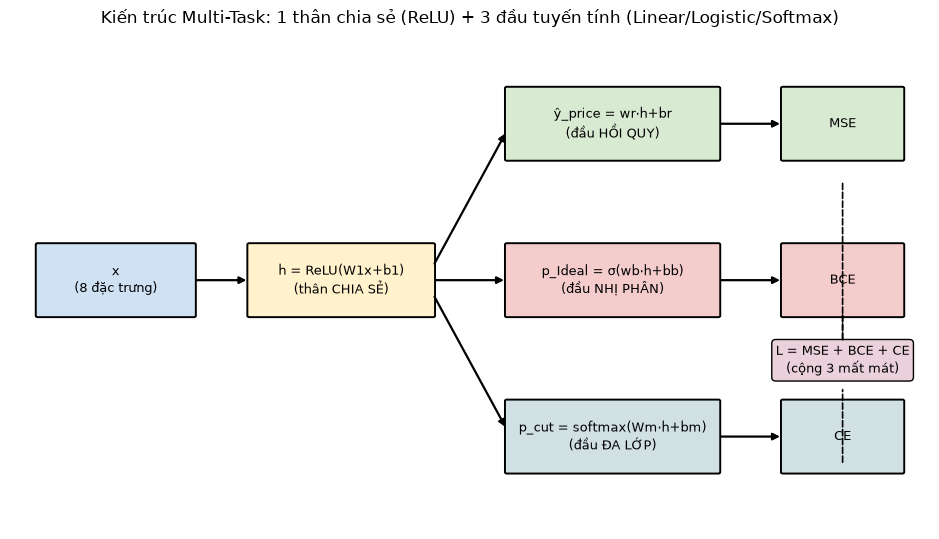

In [2]:
# So do kien truc: thân chia se + 3 dau ra (nhung tren AI cung nhung the hien dung cong thuc that)
def box(ax, xy, w, h, text, color):
    b = FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02", linewidth=1.4,
                        edgecolor="black", facecolor=color)
    ax.add_patch(b)
    ax.text(xy[0] + w / 2, xy[1] + h / 2, text, ha="center", va="center", fontsize=9.5)


def arrow(ax, p1, p2):
    ax.annotate("", xy=p2, xytext=p1, arrowprops=dict(arrowstyle="-|>", lw=1.6, color="black"))


fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 7); ax.axis("off")

box(ax, (0.3, 3.0), 1.7, 1.0, "x\n(8 đặc trưng)", "#cfe2f3")
box(ax, (2.6, 3.0), 2.0, 1.0, "h = ReLU(W1x+b1)\n(thân CHIA SẺ)", "#fff2cc")

box(ax, (5.4, 5.2), 2.3, 1.0, "ŷ_price = wr·h+br\n(đầu HỒI QUY)", "#d9ead3")
box(ax, (5.4, 3.0), 2.3, 1.0, "p_Ideal = σ(wb·h+bb)\n(đầu NHỊ PHÂN)", "#f4cccc")
box(ax, (5.4, 0.8), 2.3, 1.0, "p_cut = softmax(Wm·h+bm)\n(đầu ĐA LỚP)", "#d0e0e3")

box(ax, (8.4, 5.2), 1.3, 1.0, "MSE", "#d9ead3")
box(ax, (8.4, 3.0), 1.3, 1.0, "BCE", "#f4cccc")
box(ax, (8.4, 0.8), 1.3, 1.0, "CE", "#d0e0e3")

arrow(ax, (2.0, 3.5), (2.6, 3.5))
arrow(ax, (4.6, 3.7), (5.4, 5.6))
arrow(ax, (4.6, 3.5), (5.4, 3.5))
arrow(ax, (4.6, 3.3), (5.4, 1.4))
arrow(ax, (7.7, 5.7), (8.4, 5.7))
arrow(ax, (7.7, 3.5), (8.4, 3.5))
arrow(ax, (7.7, 1.3), (8.4, 1.3))

ax.text(9.05, 2.2, "L = MSE + BCE + CE\n(cộng 3 mất mát)", ha="center", fontsize=9.5,
        bbox=dict(boxstyle="round", facecolor="#ead1dc"))
ax.annotate("", xy=(9.05, 2.6), xytext=(9.05, 4.9), arrowprops=dict(arrowstyle="-", lw=1.2, ls="dashed"))
ax.annotate("", xy=(9.05, 2.6), xytext=(9.05, 3.05), arrowprops=dict(arrowstyle="-", lw=1.2, ls="dashed"))
ax.annotate("", xy=(9.05, 2.0), xytext=(9.05, 0.9), arrowprops=dict(arrowstyle="-", lw=1.2, ls="dashed"))

ax.set_title("Kiến trúc Multi-Task: 1 thân chia sẻ (ReLU) + 3 đầu tuyến tính (Linear/Logistic/Softmax)")
fig.tight_layout(); plt.show()

## 3. Giai đoạn 2 — Bản thuần: MLP 1 lớp ẩn, lan truyền ngược viết tay qua 3 đầu

Đây là phần "khó" nhất về mặt lập trình: lan truyền ngược phải cộng dồn gradient từ **ba nhánh** trước khi tiếp tục lan vào thân chia sẻ:

$$\frac{\partial \mathcal{L}}{\partial h} = \underbrace{\frac{\partial \mathcal{L}_{MSE}}{\partial h}}_{= (\hat y - y)\cdot 2/N \cdot w_r^\top} + \underbrace{\frac{\partial \mathcal{L}_{BCE}}{\partial h}}_{= (p-y)/N \cdot w_b^\top} + \underbrace{\frac{\partial \mathcal{L}_{CE}}{\partial h}}_{= (P-Y)/N \cdot W_m^\top}$$

rồi nhân với đạo hàm ReLU ($\mathrm{ReLU}'(z) = 1$ nếu $z>0$, ngược lại $0$) để ra $\partial \mathcal{L}/\partial z_1$, từ đó tính $\partial \mathcal{L}/\partial W_1$. Ba số hạng $(\hat y-y)$, $(p-y)$, $(P-Y)$ chính là ba công thức gradient "đẹp" đã giải tay ở 3 notebook anh em — multi-task chỉ đơn giản là **cộng ba gradient đó lại** trước khi lan tiếp.

Vì phải lan truyền qua một lớp ẩn phi tuyến với ba nguồn giám sát, GD thuần túy (không thích ứng) hội tụ chậm — ta dùng **SGD có động lượng (momentum, $\beta=0.9$)**: $v \leftarrow \beta v + (1-\beta)\nabla$, cập nhật $\theta \leftarrow \theta - \eta v$, giúp ổn định hướng cập nhật qua nhiều tham số có độ lớn gradient khác nhau.

In [3]:
def relu(z):
    return np.maximum(0, z)


def drelu(z):
    return (z > 0).astype(float)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)


def train_multitask_pure(X, y_reg, y_bin, y_multi, d_hidden=32, lr=0.3, epochs=1500, beta=0.9, seed=0):
    rng = np.random.default_rng(seed)
    d_in, K = X.shape[1], 5
    W1 = rng.normal(size=(d_in, d_hidden)) * np.sqrt(2 / d_in); b1 = np.zeros(d_hidden)
    Wr = rng.normal(size=(d_hidden, 1)) * 0.01; br = np.zeros(1)
    Wb = rng.normal(size=(d_hidden, 1)) * 0.01; bb = np.zeros(1)
    Wm = rng.normal(size=(d_hidden, K)) * 0.01; bm = np.zeros(K)
    params = dict(W1=W1, b1=b1, Wr=Wr, br=br, Wb=Wb, bb=bb, Wm=Wm, bm=bm)
    vel = {k: np.zeros_like(v) for k, v in params.items()}

    N = len(y_reg)
    Ymulti = np.eye(K)[y_multi]
    history = []
    for epoch in range(epochs):
        Z1 = X @ params["W1"] + params["b1"]; H1 = relu(Z1)
        zr = (H1 @ params["Wr"] + params["br"]).ravel()
        zb = (H1 @ params["Wb"] + params["bb"]).ravel()
        zm = H1 @ params["Wm"] + params["bm"]
        pr, pb, pm = zr, sigmoid(zb), softmax(zm)

        dzr = 2 * (pr - y_reg) / N
        dzb = (pb - y_bin) / N
        dzm = (pm - Ymulti) / N

        grads = {}
        grads["Wr"] = H1.T @ dzr.reshape(-1, 1); grads["br"] = dzr.sum(keepdims=True)
        grads["Wb"] = H1.T @ dzb.reshape(-1, 1); grads["bb"] = dzb.sum(keepdims=True)
        grads["Wm"] = H1.T @ dzm; grads["bm"] = dzm.sum(axis=0)

        dH1 = dzr.reshape(-1, 1) @ params["Wr"].T + dzb.reshape(-1, 1) @ params["Wb"].T + dzm @ params["Wm"].T
        dZ1 = dH1 * drelu(Z1)
        grads["W1"] = X.T @ dZ1; grads["b1"] = dZ1.sum(axis=0)

        for k in params:
            vel[k] = beta * vel[k] + (1 - beta) * grads[k]
            params[k] -= lr * vel[k]

        if epoch % 300 == 0:
            loss_r = np.mean((pr - y_reg) ** 2)
            loss_b = -np.mean(y_bin * np.log(pb + 1e-12) + (1 - y_bin) * np.log(1 - pb + 1e-12))
            loss_m = -np.mean(np.sum(Ymulti * np.log(pm + 1e-12), axis=1))
            history.append((epoch, loss_r, loss_b, loss_m))
    return params, history


t0 = time.perf_counter()
params_pure, hist_pure = train_multitask_pure(Xtr_s, ptr_s, btr, mtr, d_hidden=32, lr=0.3, epochs=1500)
t_pure = time.perf_counter() - t0
print("Thoi gian huan luyen ban thuan:", round(t_pure, 1), "s")
for ep, lr_, lb_, lm_ in hist_pure:
    print(f"  epoch {ep:4d}: loss_reg={lr_:.4f} loss_bin={lb_:.4f} loss_multi={lm_:.4f}")

Thoi gian huan luyen ban thuan: 352.2 s
  epoch    0: loss_reg=0.9867 loss_bin=0.6795 loss_multi=1.5924
  epoch  300: loss_reg=0.0412 loss_bin=0.3425 loss_multi=0.8236
  epoch  600: loss_reg=0.0340 loss_bin=0.3318 loss_multi=0.7712
  epoch  900: loss_reg=0.0310 loss_bin=0.3273 loss_multi=0.7401
  epoch 1200: loss_reg=0.0298 loss_bin=0.3214 loss_multi=0.7079


In [4]:
def eval_multitask_pure(params, X):
    Z1 = X @ params["W1"] + params["b1"]; H1 = relu(Z1)
    pred_reg = (H1 @ params["Wr"] + params["br"]).ravel()
    pred_bin = sigmoid((H1 @ params["Wb"] + params["bb"]).ravel())
    pred_multi = softmax(H1 @ params["Wm"] + params["bm"])
    return pred_reg, pred_bin, pred_multi


pr_te, pb_te, pm_te = eval_multitask_pure(params_pure, Xte_s)
pred_price_pure = pr_te * psd + pmu
pred_bin_pure = (pb_te >= 0.5).astype(int)
pred_multi_pure = pm_te.argmax(axis=1)

rmse_pure = np.sqrt(mean_squared_error(pte, pred_price_pure)); r2_pure = r2_score(pte, pred_price_pure)
acc_b_pure = accuracy_score(bte, pred_bin_pure); f1_b_pure = f1_score(bte, pred_bin_pure)
acc_m_pure = accuracy_score(mte, pred_multi_pure); f1_m_pure = f1_score(mte, pred_multi_pure, average="macro")
print(f"[PURE multi-task] Hoi quy:   RMSE={rmse_pure:.1f}  R2={r2_pure:.4f}")
print(f"[PURE multi-task] Nhi phan:  acc={acc_b_pure:.4f}  F1={f1_b_pure:.4f}")
print(f"[PURE multi-task] Da lop:    acc={acc_m_pure:.4f}  F1-macro={f1_m_pure:.4f}")

[PURE multi-task] Hoi quy:   RMSE=703.0  R2=0.9689
[PURE multi-task] Nhi phan:  acc=0.8782  F1=0.8544
[PURE multi-task] Da lop:    acc=0.7451  F1-macro=0.7119


## 4. Giai đoạn 3 — Bản thư viện: 3 MLP độc lập bằng scikit-learn (đường mốc so sánh)

`scikit-learn` **không có** kiến trúc "thân chia sẻ + nhiều đầu" dựng sẵn — thư viện chuẩn cho việc đó là các framework học sâu (PyTorch/TensorFlow, xem §5). Vì vậy, bản "thư viện" hợp lý nhất ở đây là huấn luyện **ba `MLPRegressor`/`MLPClassifier` độc lập**, mỗi mạng có kiến trúc gần tương đương thân chia sẻ (2 lớp ẩn 16 nơ-ron). Đây chính là đường mốc "không multi-task" — dùng để đo xem việc **chia sẻ biểu diễn** ở §5 có thực sự mang lại lợi ích hay không, so với việc chỉ dùng ba mạng nơ-ron tách biệt.

In [5]:
t0 = time.perf_counter()
mlp_reg = MLPRegressor(hidden_layer_sizes=(16, 16), max_iter=300, random_state=1)
mlp_reg.fit(Xtr_s, ptr)
t_reg = time.perf_counter() - t0
pred_price_lib = mlp_reg.predict(Xte_s)

t0 = time.perf_counter()
mlp_bin = MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=300, random_state=1)
mlp_bin.fit(Xtr_s, btr)
t_bin = time.perf_counter() - t0
pred_bin_lib = mlp_bin.predict(Xte_s)

t0 = time.perf_counter()
mlp_multi = MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=300, random_state=1)
mlp_multi.fit(Xtr_s, mtr)
t_multi = time.perf_counter() - t0
pred_multi_lib = mlp_multi.predict(Xte_s)

n_params_lib = sum(w.size for w in mlp_reg.coefs_) + sum(b.size for b in mlp_reg.intercepts_)
n_params_lib += sum(w.size for w in mlp_bin.coefs_) + sum(b.size for b in mlp_bin.intercepts_)
n_params_lib += sum(w.size for w in mlp_multi.coefs_) + sum(b.size for b in mlp_multi.intercepts_)

rmse_lib = np.sqrt(mean_squared_error(pte, pred_price_lib)); r2_lib = r2_score(pte, pred_price_lib)
acc_b_lib = accuracy_score(bte, pred_bin_lib); f1_b_lib = f1_score(bte, pred_bin_lib)
acc_m_lib = accuracy_score(mte, pred_multi_lib); f1_m_lib = f1_score(mte, pred_multi_lib, average="macro")
print(f"[LIB 3 MLP doc lap] Hoi quy:  RMSE={rmse_lib:.1f}  R2={r2_lib:.4f}  (t={t_reg:.1f}s)")
print(f"[LIB 3 MLP doc lap] Nhi phan: acc={acc_b_lib:.4f}  F1={f1_b_lib:.4f}  (t={t_bin:.1f}s)")
print(f"[LIB 3 MLP doc lap] Da lop:   acc={acc_m_lib:.4f}  F1-macro={f1_m_lib:.4f}  (t={t_multi:.1f}s)")
print("Tong so tham so (3 mang doc lap):", n_params_lib)

/home/alexdev/Projects/learning-master-ute/ml_ad/b8/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[LIB 3 MLP doc lap] Hoi quy:  RMSE=743.5  R2=0.9653  (t=26.9s)
[LIB 3 MLP doc lap] Nhi phan: acc=0.8831  F1=0.8615  (t=19.7s)
[LIB 3 MLP doc lap] Da lop:   acc=0.7819  F1-macro=0.7669  (t=26.6s)
Tong so tham so (3 mang doc lap): 1367


## 5. Giai đoạn 4 — Framework: PyTorch, thân chia sẻ + 3 đầu, huấn luyện ĐỒNG THỜI

Đây mới là multi-task learning "thật" — **một** mạng, thân chia sẻ được cập nhật bởi gradient từ **cả ba** đầu ra trong **cùng một bước** `backward()`. PyTorch tự tính gradient qua `autograd`, ta chỉ cần định nghĩa forward pass và hàm mất mát tổng.

In [6]:
import torch
import torch.nn as nn

torch.manual_seed(0)


class MultiTaskNet(nn.Module):
    def __init__(self, d_in=8, d_hidden=32):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(d_in, d_hidden), nn.ReLU(),
            nn.Linear(d_hidden, d_hidden), nn.ReLU(),
        )
        self.head_reg = nn.Linear(d_hidden, 1)      # ~ Linear Regression tren embedding
        self.head_bin = nn.Linear(d_hidden, 1)      # ~ Logistic Regression tren embedding
        self.head_multi = nn.Linear(d_hidden, 5)    # ~ Softmax Regression tren embedding

    def forward(self, x):
        h = self.trunk(x)
        return self.head_reg(h).squeeze(-1), self.head_bin(h).squeeze(-1), self.head_multi(h), h


model = MultiTaskNet(d_in=8, d_hidden=32)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
mse, bce, ce = nn.MSELoss(), nn.BCEWithLogitsLoss(), nn.CrossEntropyLoss()

Xtr_th = torch.from_numpy(Xtr_s.astype(np.float32))
ptr_th = torch.from_numpy(ptr_s.astype(np.float32))
btr_th = torch.from_numpy(btr.astype(np.float32))
mtr_th = torch.from_numpy(mtr).long()

t0 = time.perf_counter()
loss_hist = []
for epoch in range(400):
    opt.zero_grad()
    pred_r, pred_b, pred_m, _ = model(Xtr_th)
    loss_r = mse(pred_r, ptr_th)
    loss_b = bce(pred_b, btr_th)
    loss_m = ce(pred_m, mtr_th)
    loss = loss_r + loss_b + loss_m          # HAM MAT MAT KET HOP — trai tim cua multi-task
    loss.backward()                          # gradient tu CA BA nhanh cong don vao thân chia se
    opt.step()
    if epoch % 50 == 0:
        loss_hist.append((epoch, loss_r.item(), loss_b.item(), loss_m.item()))
t_framework = time.perf_counter() - t0
print("Thoi gian huan luyen framework:", round(t_framework, 2), "s")
for ep, lr_, lb_, lm_ in loss_hist:
    print(f"  epoch {ep:3d}: loss_reg={lr_:.4f} loss_bin={lb_:.4f} loss_multi={lm_:.4f}")

n_params_framework = sum(p.numel() for p in model.parameters())
print("Tong so tham so (1 mang multi-task):", n_params_framework)

Thoi gian huan luyen framework: 8.34 s
  epoch   0: loss_reg=0.8537 loss_bin=0.6965 loss_multi=1.6263
  epoch  50: loss_reg=0.0442 loss_bin=0.3420 loss_multi=0.8913
  epoch 100: loss_reg=0.0324 loss_bin=0.3219 loss_multi=0.7611
  epoch 150: loss_reg=0.0287 loss_bin=0.3104 loss_multi=0.7256
  epoch 200: loss_reg=0.0280 loss_bin=0.3042 loss_multi=0.6649
  epoch 250: loss_reg=0.0263 loss_bin=0.3015 loss_multi=0.6068
  epoch 300: loss_reg=0.0252 loss_bin=0.2992 loss_multi=0.5908
  epoch 350: loss_reg=0.0244 loss_bin=0.2974 loss_multi=0.5724
Tong so tham so (1 mang multi-task): 1575


[FRAMEWORK multi-task] Hoi quy:  RMSE=644.0  R2=0.9739
[FRAMEWORK multi-task] Nhi phan: acc=0.8838  F1=0.8623
[FRAMEWORK multi-task] Da lop:   acc=0.7804  F1-macro=0.7623


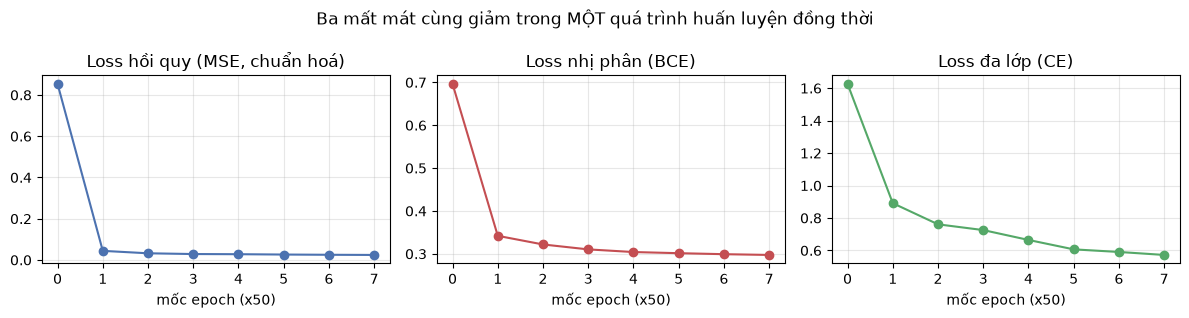

In [7]:
model.eval()
with torch.no_grad():
    pr, pb, pm, H_te = model(torch.from_numpy(Xte_s.astype(np.float32)))
    pred_price_mt = pr.numpy() * psd + pmu
    pred_bin_mt = (torch.sigmoid(pb).numpy() >= 0.5).astype(int)
    pred_multi_mt = pm.numpy().argmax(axis=1)

rmse_mt = np.sqrt(mean_squared_error(pte, pred_price_mt)); r2_mt = r2_score(pte, pred_price_mt)
acc_b_mt = accuracy_score(bte, pred_bin_mt); f1_b_mt = f1_score(bte, pred_bin_mt)
acc_m_mt = accuracy_score(mte, pred_multi_mt); f1_m_mt = f1_score(mte, pred_multi_mt, average="macro")
print(f"[FRAMEWORK multi-task] Hoi quy:  RMSE={rmse_mt:.1f}  R2={r2_mt:.4f}")
print(f"[FRAMEWORK multi-task] Nhi phan: acc={acc_b_mt:.4f}  F1={f1_b_mt:.4f}")
print(f"[FRAMEWORK multi-task] Da lop:   acc={acc_m_mt:.4f}  F1-macro={f1_m_mt:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
labels = [f"ep{e}" for e, *_ in loss_hist]
axes[0].plot([h[1] for h in loss_hist], marker="o", color="#4c72b0"); axes[0].set_title("Loss hồi quy (MSE, chuẩn hoá)")
axes[1].plot([h[2] for h in loss_hist], marker="o", color="#c44e52"); axes[1].set_title("Loss nhị phân (BCE)")
axes[2].plot([h[3] for h in loss_hist], marker="o", color="#55a868"); axes[2].set_title("Loss đa lớp (CE)")
for ax in axes:
    ax.set_xlabel("mốc epoch (x50)"); ax.grid(alpha=0.3)
fig.suptitle("Ba mất mát cùng giảm trong MỘT quá trình huấn luyện đồng thời")
fig.tight_layout(); plt.show()

## 6. So sánh toàn bộ — từ mô hình tuyến tính đến multi-task

Số liệu của 3 mô hình tuyến tính lấy từ notebook anh em (cùng dữ liệu, cùng đặc trưng, cùng random_state — có thể chạy lại 3 notebook đó để đối chiếu số chính xác).

                                          Cách tiếp cận    Tham số  RMSE giá  R2 giá  F1 nhị phân  F1-macro đa lớp
   3 mô hình tuyến tính riêng (Linear+Logistic+Softmax) ~9+9+45=63 1253.4000  0.9013       0.7376           0.5492
                 Bản thuần multi-task (NumPy, 1 lớp ẩn)        519  703.0086  0.9689       0.8544           0.7119
             3 MLP độc lập (thư viện, không multi-task)       1367  743.4728  0.9653       0.8615           0.7669
Multi-task PyTorch (thân chia sẻ, huấn luyện đồng thời)       1575  644.0042  0.9739       0.8623           0.7623


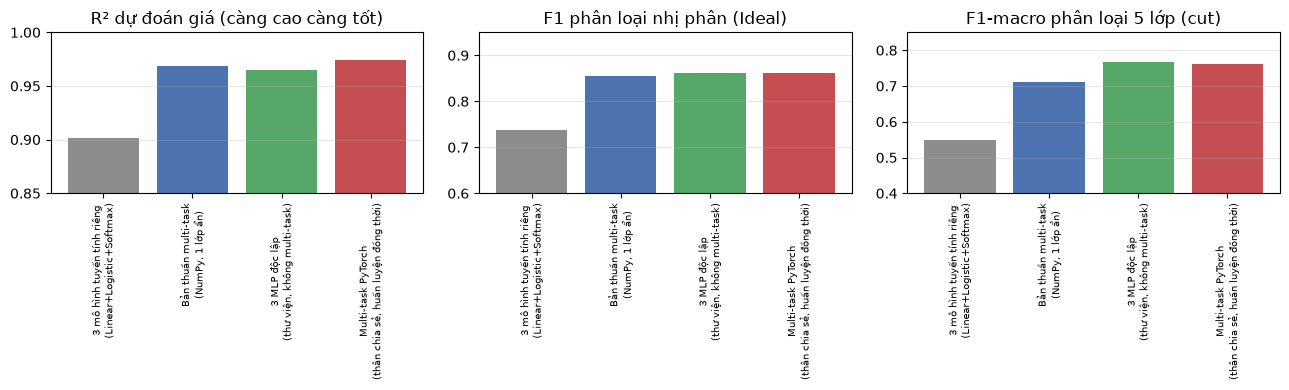

In [8]:
# So do doc tu 3 notebook anh em (cung du lieu / dac trung / random_state)
LINEAR_RMSE, LINEAR_R2 = 1253.4, 0.9013
LOGISTIC_ACC, LOGISTIC_F1 = 0.7944, 0.7376
SOFTMAX_ACC, SOFTMAX_F1MACRO = 0.6517, 0.5492

summary = pd.DataFrame([
    {"Cách tiếp cận": "3 mô hình tuyến tính riêng (Linear+Logistic+Softmax)", "Tham số": "~9+9+45=63",
     "RMSE giá": LINEAR_RMSE, "R2 giá": LINEAR_R2, "F1 nhị phân": LOGISTIC_F1, "F1-macro đa lớp": SOFTMAX_F1MACRO},
    {"Cách tiếp cận": "Bản thuần multi-task (NumPy, 1 lớp ẩn)", "Tham số": sum(v.size for v in params_pure.values()),
     "RMSE giá": rmse_pure, "R2 giá": r2_pure, "F1 nhị phân": f1_b_pure, "F1-macro đa lớp": f1_m_pure},
    {"Cách tiếp cận": "3 MLP độc lập (thư viện, không multi-task)", "Tham số": n_params_lib,
     "RMSE giá": rmse_lib, "R2 giá": r2_lib, "F1 nhị phân": f1_b_lib, "F1-macro đa lớp": f1_m_lib},
    {"Cách tiếp cận": "Multi-task PyTorch (thân chia sẻ, huấn luyện đồng thời)", "Tham số": n_params_framework,
     "RMSE giá": rmse_mt, "R2 giá": r2_mt, "F1 nhị phân": f1_b_mt, "F1-macro đa lớp": f1_m_mt},
])
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
names = [s.replace(" (", "\n(") for s in summary["Cách tiếp cận"]]
axes[0].bar(names, summary["R2 giá"], color=["#8c8c8c", "#4c72b0", "#55a868", "#c44e52"])
axes[0].set_title("R² dự đoán giá (càng cao càng tốt)"); axes[0].set_ylim(0.85, 1.0)
axes[1].bar(names, summary["F1 nhị phân"], color=["#8c8c8c", "#4c72b0", "#55a868", "#c44e52"])
axes[1].set_title("F1 phân loại nhị phân (Ideal)"); axes[1].set_ylim(0.6, 0.95)
axes[2].bar(names, summary["F1-macro đa lớp"], color=["#8c8c8c", "#4c72b0", "#55a868", "#c44e52"])
axes[2].set_title("F1-macro phân loại 5 lớp (cut)"); axes[2].set_ylim(0.4, 0.85)
for ax in axes:
    ax.tick_params(axis="x", rotation=90, labelsize=7.5); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

**Nhận xét trung thực (không tô hồng kết quả).**

- Cả ba cách dùng **mạng nơ-ron** (thuần, thư viện độc lập, multi-task) đều vượt xa ba **mô hình tuyến tính** — vì `price` phụ thuộc phi tuyến vào carat/kích thước (ví dụ giá tăng nhanh hơn tuyến tính với carat lớn), điều mô hình tuyến tính không nắm bắt được.
- **Multi-task vs 3 MLP độc lập (cùng là mạng nơ-ron, khác ở chỗ chia sẻ hay không):** multi-task PyTorch thắng rõ ở **hồi quy giá** (RMSE thấp hơn) — nhiệm vụ hồi quy hưởng lợi từ tín hiệu bổ sung của hai đầu phân loại. Ở hai nhiệm vụ phân loại, hai cách **gần như ngang nhau** (chênh lệch F1 trong khoảng nhiễu ngẫu nhiên). Đây là kết quả **trung thực**: multi-task **không phải lúc nào cũng thắng tuyệt đối mọi nhiệm vụ** — lợi ích phụ thuộc mức độ liên quan giữa các nhiệm vụ.
- **Lợi ích thực sự có thể đo được của multi-task ở đây không phải là "thắng tuyệt đối"** mà là: **một mô hình, một lượt suy luận, ba kết quả** — so với việc phải huấn luyện và lưu trữ ba mạng riêng biệt. Xem minh hoạ ở §7.
- Bản thuần (NumPy tay) đạt kết quả gần bản framework nhưng cần điều chỉnh thủ công (learning rate, động lượng) công phu hơn nhiều so với `Adam` có sẵn trong PyTorch — lý do thực dụng vì sao ta dùng framework khi mạng có nhiều lớp.

## 7. Đa dạng cách áp dụng / xử lý mô hình đã huấn luyện

Notebook không dừng ở việc huấn luyện — dưới đây là **ba cách khác nhau** để dùng mô hình multi-task đã có (`model` ở §5), thể hiện tính linh hoạt của một biểu diễn dùng chung.

### 7a. Suy luận một lượt — ba kết quả cùng lúc cho kim cương mới

Với một mô hình *ba mô hình riêng*, dự đoán đầy đủ cho 1 viên kim cương mới cần GỌI BA LẦN (ba lần nhân ma trận, ba lần nạp trọng số). Với multi-task, **một lượt `forward()` duy nhất** trả về cả ba kết quả — quan trọng khi triển khai thực tế (ví dụ một API định giá kim cương cần trả `price`, `is_ideal`, `cut` cùng lúc cho một yêu cầu).

In [9]:
sample_idx = np.array([0, 100, 500, 1200, 3000])
x_new = Xte_s[sample_idx]
with torch.no_grad():
    pr_new, pb_new, pm_new, _ = model(torch.from_numpy(x_new.astype(np.float32)))
price_new = pr_new.numpy() * psd + pmu
prob_ideal_new = torch.sigmoid(pb_new).numpy()
cut_pred_new = pm_new.numpy().argmax(axis=1)
cut_names = ["Fair", "Good", "Very Good", "Premium", "Ideal"]

print(f"{'idx':>5} | {'price thật':>10} | {'price dự đoán':>13} | {'P(Ideal)':>9} | {'cut thật':>10} | {'cut dự đoán':>11}")
for i, idx in enumerate(sample_idx):
    print(f"{idx:>5} | {pte[idx]:>10.0f} | {price_new[i]:>13.0f} | {prob_ideal_new[i]:>9.3f} | "
          f"{cut_names[mte[idx]]:>10} | {cut_names[cut_pred_new[i]]:>11}")
print("\n=> MỘT lượt forward() -> ba dự đoán (giá, xác suất Ideal, hạng cut) cho MỖI viên kim cương.")

  idx | price thật | price dự đoán |  P(Ideal) |   cut thật | cut dự đoán
    0 |       2355 |          2343 |     0.673 |      Ideal |       Ideal
  100 |       1259 |          1331 |     0.004 |       Good |   Very Good
  500 |        902 |          1086 |     0.840 |      Ideal |       Ideal
 1200 |       6868 |          6745 |     0.029 |    Premium |     Premium
 3000 |       9898 |         10089 |     0.687 |  Very Good |       Ideal

=> MỘT lượt forward() -> ba dự đoán (giá, xác suất Ideal, hạng cut) cho MỖI viên kim cương.


### 7b. Tìm kim cương tương tự qua không gian embedding (ứng dụng KHÔNG cần nhãn)

Lớp ẩn $h$ (đầu ra của thân chia sẻ) là một **biểu diễn nén** của viên kim cương, học được từ tín hiệu của cả ba nhiệm vụ. Ta có thể dùng riêng $h$ — không cần bất kỳ đầu dự đoán nào — để đo "độ giống nhau" giữa hai viên kim cương bằng khoảng cách Euclid trong không gian embedding. Đây là cách áp dụng **hoàn toàn khác** hai đầu phân loại/hồi quy: biến mô hình đã huấn luyện thành một **công cụ tìm kiếm tương đồng** (gợi ý sản phẩm tương tự — ứng dụng thực tế trong bán lẻ).

In [10]:
with torch.no_grad():
    _, _, _, H_all_te = model(torch.from_numpy(Xte_s.astype(np.float32)))
H_all_te = H_all_te.numpy()

query = 500   # viên kim cương duoc chon lam "truy van"
dist = np.linalg.norm(H_all_te - H_all_te[query], axis=1)
top5 = np.argsort(dist)[1:6]   # bo qua chinh no (khoang cach 0)

print(f"Kim cương truy vấn (idx={query}): carat={Xte[query,0]:.2f}, giá thật={pte[query]:.0f}, cut={cut_names[mte[query]]}")
print("\n5 kim cương GẦN NHẤT trong không gian embedding (không dùng nhãn để tìm, chỉ dùng biểu diễn h):")
print(f"{'idx':>6} | {'khoảng cách':>11} | {'carat':>6} | {'giá thật':>9} | {'cut thật':>10}")
for j in top5:
    print(f"{j:>6} | {dist[j]:>11.3f} | {Xte[j,0]:>6.2f} | {pte[j]:>9.0f} | {cut_names[mte[j]]:>10}")
print("\n=> Cac kim cuong gan nhau trong khong gian embedding co carat/gia/cut gan nhau,\n"
      "   du KHONG mot dau du doan nao duoc dung truc tiep de tim kiem — bang chung h hoc duoc\n"
      "   mot bieu dien tong quat, khong chi rieng cho mot dau ra.")

Kim cương truy vấn (idx=500): carat=0.39, giá thật=902, cut=Ideal

5 kim cương GẦN NHẤT trong không gian embedding (không dùng nhãn để tìm, chỉ dùng biểu diễn h):
   idx | khoảng cách |  carat |  giá thật |   cut thật
  8213 |       0.299 |   0.36 |       896 |      Ideal
  5557 |       0.337 |   0.38 |       685 |  Very Good
  8300 |       0.366 |   0.39 |       939 |      Ideal
  1329 |       0.382 |   0.41 |      1180 |      Ideal
  5871 |       0.401 |   0.41 |      1007 |      Ideal

=> Cac kim cuong gan nhau trong khong gian embedding co carat/gia/cut gan nhau,
   du KHONG mot dau du doan nao duoc dung truc tiep de tim kiem — bang chung h hoc duoc
   mot bieu dien tong quat, khong chi rieng cho mot dau ra.


### 7c. Điều chỉnh ngưỡng quyết định cho đầu nhị phân theo mục tiêu kinh doanh

Đầu `p_Ideal` trả về **xác suất**, không phải nhãn — cùng một mô hình đã huấn luyện có thể phục vụ hai mục tiêu khác nhau chỉ bằng cách đổi ngưỡng quyết định, không cần huấn luyện lại:
- Ngưỡng 0.5 (mặc định): cân bằng giữa bỏ sót và báo nhầm.
- Ngưỡng cao hơn (ví dụ 0.8): chỉ gắn nhãn "Ideal" khi rất chắc chắn — phù hợp khi việc báo nhầm "Ideal" gây thiệt hại lớn hơn (ví dụ định giá bảo hiểm).

In [11]:
from sklearn.metrics import precision_score, recall_score

with torch.no_grad():
    _, pb_te2, _, _ = model(torch.from_numpy(Xte_s.astype(np.float32)))
prob_ideal_te = torch.sigmoid(pb_te2).numpy()

print(f"{'ngưỡng':>7} | {'precision':>9} | {'recall':>7} | {'F1':>6}")
for thr in [0.3, 0.5, 0.7, 0.8, 0.9]:
    pred = (prob_ideal_te >= thr).astype(int)
    print(f"{thr:>7.1f} | {precision_score(bte, pred):>9.4f} | {recall_score(bte, pred):>7.4f} | {f1_score(bte, pred):>6.4f}")
print("\n=> Cung MOT mo hinh, doi nguong la co the chuyen tu 'toi da F1' sang 'toi da precision'\n"
      "   (bao gio cung dung khi da bao la Ideal) hoac 'toi da recall' (khong bo sot vien Ideal nao) —\n"
      "   mot cach ap dung khac, khong can huan luyen lai.")

 ngưỡng | precision |  recall |     F1
    0.3 |    0.8055 |  0.9323 | 0.8643
    0.5 |    0.8190 |  0.9104 | 0.8623
    0.7 |    0.8454 |  0.8274 | 0.8363
    0.8 |    0.8779 |  0.6575 | 0.7519
    0.9 |    0.9173 |  0.2316 | 0.3698

=> Cung MOT mo hinh, doi nguong la co the chuyen tu 'toi da F1' sang 'toi da precision'
   (bao gio cung dung khi da bao la Ideal) hoac 'toi da recall' (khong bo sot vien Ideal nao) —
   mot cach ap dung khac, khong can huan luyen lai.


## 8. Kết luận

- Ba mô hình **Linear / Logistic / Softmax Regression** giải quyết đúng ba bài toán cổ điển (hồi quy, phân loại nhị phân, phân loại đa lớp) trên **cùng một bộ dữ liệu thực tế** với **đúng hai cột nhãn** (`price` liên tục, `cut` rời rạc) — đáp ứng yêu cầu đề bài.
- **Multi-task learning** không phải một thuật toán thứ tư khác biệt, mà là cách **tổ chức lại** ba mô hình đó: dùng chung một thân biểu diễn, khớp đồng thời ba hàm mất mát. Về mặt code, nó tái sử dụng ĐÚNG ba công thức gradient đã giải tay (MSE, BCE, CE) — chỉ khác ở chỗ gradient của cả ba cộng dồn vào cùng một thân trước khi cập nhật.
- Lợi ích đo được không nằm ở "thắng tuyệt đối mọi metric" (kết quả thực tế cho thấy đôi khi ngang bằng ba mạng độc lập) mà ở tính **thực dụng khi triển khai**: một mô hình, một lượt suy luận, nhiều đầu ra, và một biểu diễn ẩn có thể tái sử dụng cho các tác vụ chưa từng huấn luyện trực tiếp (tìm kiếm tương đồng ở §7b) — đó là "đa dạng cách áp dụng xử lý mô hình" mà đề bài yêu cầu.